# PE6201 A2 · Health Insurance · Cost Analysis
Edit the inputs in **Section 1**, then select **Run All**. Calculations use the teacher's Class 5 formulas and require no API calls.

## Project background and assumptions

| Item | Basis |
|---|---|
| V1 evaluation | Qwen3.8 Flash, live V1: 40 cases, 72 runs (24 once; 16 three times), 56 passed and 16 failed; run timestamp 2026-09-19 14:51:49 |
| V2 evaluation | Five models; 40 cases per model: 24 approval cases run once and 16 negative cases run three times = **72 runs per model**, 360 runs in total |
| Success rate | Passed runs ÷ total runs, using the existing grader; correct requests for documents and escalations can count as passes |
| Monthly workload | **8,000 claims**, specified in A2 Problem A; this is a forecast workload, not the number tested |
| Human correction cost | **$38/hour × 12 minutes ÷ 60 = $7.60 per failed task**, specified in A2 Problem A |
| Average human cost per task | Failure rate × $7.60 |
| Token cost | Recorded batch input/output tokens × their respective ordinary prices, divided by batch runs; no caching discount in the baseline |
| Currency | USD throughout |

**Fixed monthly budget: $118.92 — planning estimates, not actual bills.**

| Component | Monthly USD | Basis |
|---|---:|---|
| Singapore server | 12.00 | Selected AWS Lightsail Linux plan: 2GB RAM and 60GB SSD |
| Archive / backup storage | 3.00 | Selected 100GB object-storage plan; planning allowance of 100KB/claim × 8,000 × 12 months × 2 copies ≈ 19.2GB; excludes PDF/image attachments |
| Basic monitoring | 0.00 | Included service metrics; no separate monitoring subscription |
| Maintenance | 100.00 | Assumed 4 hours/month × $25/hour |
| Evaluation | 3.92 | Four 72-run batches/month × measured Claude batch cost $0.979239, rounded |
| **Total** | **118.92** | Shared fixed budget for each alternative model-deployment scenario |

Infrastructure price references: [AWS Lightsail pricing](https://aws.amazon.com/lightsail/pricing/) and [FAQ](https://aws.amazon.com/lightsail/faq/). Replace estimates when actual bills are available.

**Data notes:** V2 source snapshot `93238a8`; V1 source snapshot `cbfd25b`. Exact run sources appear below. Qwen V2 has two runs with incomplete usage, so its costs are provisional; V1 usage is complete for all 72 runs. Separate tool fees are assumed to be $0 because none are reported in these inputs. Grader pass rates are test measurements, not guaranteed production accuracy; the grader does not fully validate every amount and line disposition. Sensitivity results are hypothetical scenarios, not confidence intervals.



## Section 1 · Inputs
### 1A · Business assumptions
Set monthly volume, human correction cost and fixed monthly expenses. Set `EXPORT_TABLES = True` if separate CSVs and charts are needed.

In [ ]:
import json, math
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

SETTINGS = {
    "monthly_volume": 8000,       # Assignment volume assumption; not an enforced user quota
    "labour_usd_per_hour": 38.0,
    "minutes_per_failure": 12.0,
    "reference_model": "anthropic/claude-haiku-4.5",
    "sensitivity_offsets_pp": [-10, -5, 0, 5, 10],
}
FIXED_ITEMS = [
    # Item, monthly USD, and basis; update the basis if plans change
    {"item": "Singapore server", "monthly_usd": 12.00, "basis": "Planning estimate: AWS Lightsail Linux public IPv4, 2GB RAM / 60GB SSD"},
    {"item": "Archive / backup storage", "monthly_usd": 3.00, "basis": "Planning estimate: 100GB Lightsail object storage"},
    {"item": "Basic monitoring", "monthly_usd": 0.00, "basis": "Included basic Lightsail metrics; no external monitoring subscription"},
    {"item": "Maintenance", "monthly_usd": 100.00, "basis": "Assumption: 4 hours/month x USD25/hour; not a quoted wage"},
    {"item": "Evaluation budget", "monthly_usd": 3.92, "basis": "Planning estimate: 4 batches x USD0.979239, rounded monthly allowance"},
]
EXPORT_TABLES = False             # True: export CSVs and input JSON; overwrites files with matching names
OUTPUT_DIR = Path("d6_cost_outputs")

### 1B · V1 data
Prefilled from Karthik's live Qwen3.8 Flash V1 batch: 72 runs, 56 passes. Baseline costs use ordinary token prices; the API-reported batch charge is retained separately as a reference.

In [ ]:
V1_ENABLED = True
V1_COMPARISON_ENABLED = True
V1 = {
    "model": "qwen/qwen3.8-flash",
    "version": "v1",
    "total_runs": 72,
    "passed_runs": 56,
    "input_tokens": 576968,
    "output_tokens": 59926,          # Includes reasoning; do not add it again
    "input_price": 0.15,             # USD per million input tokens
    "output_price": 0.47,            # USD per million output tokens
    "unknown_usage_runs": 0,
    "extra_fee_per_task": 0.0,       # Assumption: no separately reported tool fee
    "source": "https://github.com/symbioticshark/A2_HealthInsurance/blob/cbfd25beff87f2183884aecc2988ea6059fa89b0/A2_thirdBuild/results/karthik/karthik_result.json",
    "run_id": "1789799429-8f9a0653",
    "run_timestamp": "2026-09-19 14:51:49",
    "api_reported_batch_cost_usd": 0.0512824,  # Sum of 72 case costs; reference only
}
V1_V2_MATCH = {
    "v2_model": "qwen/qwen3.8-flash",
    "same_case_set_and_repetitions": True,
    "same_prompt_guards_and_settings": False,
    "evidence_note": "Same model ID, case IDs and repetition plan in the recorded comparison. V1 app version 3.0; V2 app version 2.5. Other settings are not confirmed identical.",
    "v1_mean_tool_return_tokens": None,
    "v2_mean_tool_return_tokens": None,
    "tool_token_measurement_method": "",
}


### 1C · V2 data
Enter each model's total runs, passed runs, **batch token totals**, USD prices per million tokens and source reference. Averages and success rates are calculated automatically. Record incomplete usage in `unknown_usage_runs`.

In [ ]:
MODELS = [{'model': 'anthropic/claude-haiku-4.5',
  'version': 'v2',
  'total_runs': 72,
  'passed_runs': 72,
  'input_tokens': 722204,
  'output_tokens': 51407,
  'input_price': 1,
  'output_price': 5,
  'unknown_usage_runs': 0,
  'source': 'https://github.com/symbioticshark/A2_HealthInsurance/blob/93238a8e630de2d64668e9c69837c1da1c2d91c5/A2_thirdBuild/results/lingenxin/lingrnxin_result.json',
  'run_id': '1789651572-01f9a7e4',
  'run_timestamp': '2026-09-17 21:26:12',
  'extra_fee_per_task': 0.0},
 {'model': 'deepseek/deepseek-v3.2',
  'version': 'v2',
  'total_runs': 72,
  'passed_runs': 71,
  'input_tokens': 665777,
  'output_tokens': 51317,
  'input_price': 0.26899999999999996,
  'output_price': 0.39999999999999997,
  'unknown_usage_runs': 0,
  'source': 'https://github.com/symbioticshark/A2_HealthInsurance/blob/93238a8e630de2d64668e9c69837c1da1c2d91c5/A2_thirdBuild/results/xinrongshao/xinrongshao_result.json',
  'run_id': '1789566500-c35e4bdc',
  'run_timestamp': '2026-09-16 21:48:20',
  'extra_fee_per_task': 0.0},
 {'model': 'google/gemini-2.5-flash',
  'version': 'v2',
  'total_runs': 72,
  'passed_runs': 68,
  'input_tokens': 686431,
  'output_tokens': 48473,
  'input_price': 0.3,
  'output_price': 2.5,
  'unknown_usage_runs': 0,
  'source': 'https://github.com/symbioticshark/A2_HealthInsurance/blob/93238a8e630de2d64668e9c69837c1da1c2d91c5/A2_thirdBuild/results/zhangpeiqi/zhangpeiqi_result.json',
  'run_id': '1789488873-28da5331',
  'run_timestamp': '2026-09-16 00:14:33',
  'extra_fee_per_task': 0.0},
 {'model': 'qwen/qwen3.8-flash',
  'version': 'v2',
  'total_runs': 72,
  'passed_runs': 64,
  'input_tokens': 583545,
  'output_tokens': 56827,
  'input_price': 0.15,
  'output_price': 0.47,
  'unknown_usage_runs': 2,
  'source': 'https://github.com/symbioticshark/A2_HealthInsurance/blob/93238a8e630de2d64668e9c69837c1da1c2d91c5/A2_thirdBuild/results/wengyongting/wengyongting_result.json',
  'run_id': '1789636210-ac405435',
  'run_timestamp': '2026-09-17 17:10:10',
  'extra_fee_per_task': 0.0},
 {'model': 'meta-llama/llama-3.3-70b-instruct',
  'version': 'v2',
  'total_runs': 72,
  'passed_runs': 57,
  'input_tokens': 612897,
  'output_tokens': 29363,
  'input_price': 0.09999999999999999,
  'output_price': 0.32,
  'unknown_usage_runs': 0,
  'source': 'https://github.com/symbioticshark/A2_HealthInsurance/blob/93238a8e630de2d64668e9c69837c1da1c2d91c5/A2_thirdBuild/results/chenyayue/chenyayue_result.json',
  'run_id': '1789573134-fdbfdc0b',
  'run_timestamp': '2026-09-16 23:38:54',
  'extra_fee_per_task': 0.0}]

## Section 2 · Cost formulas
Reuses the teacher's functions for token costs, expected human correction costs, monthly totals and break-even success rates.

In [ ]:
def agent_input_tokens(base, growth, turns):
    """Input tokens an agent sends across a whole run.

    The API is STATELESS. Nothing is remembered between calls, so the whole
    conversation so far is re-sent as input on every turn. Turn t sends
    base + growth*(t-1), and summed over T turns:

        base*T  +  growth * T*(T-1)/2        <- quadratic in turns, not linear

    Keep the two terms in proportion. base*T is LINEAR (the fixed prompt re-sent
    every turn); only the second term is quadratic. The quadratic one overtakes
    the linear one at turns > 2*base/growth + 1 -- about 15 turns for 5,500/800.
    At 6 turns it is only ~27% of the bill, so on short loops shrink `base` first.

    `growth` is everything one completed turn adds to the conversation:

        growth = the model's own reply (its thought + chosen action)
               + the observation the tool returned

    Both halves are re-sent as INPUT on every later turn. So the model's reply is
    paid for twice over: ONCE at the OUTPUT price, on the turn it is written, and
    then at the INPUT price on every turn after that. There is nothing further to
    add for replies -- they are already inside `growth`.
    """
    return base * turns + growth * turns * (turns - 1) // 2


def variable_cost(tier, fresh_in=0, cached_in=0, out=0, retrieval_usd=0.0, tool_usd=0.0):
    "LAYER 1 — per-task variable cost, US dollars."
    p = PRICES[tier]
    assert fresh_in >= 0 and cached_in >= 0 and out >= 0, "token counts cannot be negative"
    return (fresh_in / 1e6 * p["in"]
            + cached_in / 1e6 * p["cached_in"]
            + out / 1e6 * p["out"]
            + retrieval_usd + tool_usd)


def cost_per_successful_task(var_usd, success_rate, failure_usd):
    "LAYER 1 + LAYER 2. The number to quote."
    assert 0.0 <= success_rate <= 1.0, "success rate is a probability, not a percentage"
    assert failure_usd >= 0, "a failure cannot cost less than nothing"
    return var_usd + (1.0 - success_rate) * failure_usd


def monthly(var_usd, success_rate, failure_usd, volume, fixed_monthly_usd=0.0):
    "Everything, for a month."
    return cost_per_successful_task(var_usd, success_rate, failure_usd) * volume + fixed_monthly_usd


def break_even_success_rate(cheap_var, dear_total, failure_usd):
    """The success rate the CHEAP option needs to match the expensive one.

    cheap_var + (1-p) * failure = dear_total   ->   p = 1 - (dear_total - cheap_var)/failure
    """
    p = 1.0 - (dear_total - cheap_var) / failure_usd
    return max(0.0, min(1.0, p))

## Section 3 · Input checks
Checks data ranges and displays the fixed budget and source links. Missing usage is flagged rather than treated as free.

In [ ]:
assert SETTINGS["monthly_volume"] > 0
assert SETTINGS["labour_usd_per_hour"] > 0 and SETTINGS["minutes_per_failure"] > 0
assert all(x["monthly_usd"] >= 0 for x in FIXED_ITEMS)
assert len({r["model"] for r in MODELS}) == len(MODELS), "Duplicate model names: select one comparable batch per model"
PRICES = {}
for r in MODELS:
    assert r["version"].lower() == "v2", "The MODELS input block is reserved for V2"
    assert isinstance(r["total_runs"], int) and r["total_runs"] > 0
    assert isinstance(r["passed_runs"], int) and 0 <= r["passed_runs"] <= r["total_runs"]
    assert isinstance(r["unknown_usage_runs"], int) and 0 <= r["unknown_usage_runs"] <= r["total_runs"]
    for k in ["input_tokens", "output_tokens", "input_price", "output_price", "extra_fee_per_task"]:
        assert math.isfinite(r[k]) and r[k] >= 0, f"Invalid {k} for {r['model']}"
    assert r["source"], "Provide a source reference"
    PRICES[r["model"]] = {"in": r["input_price"], "out": r["output_price"], "cached_in": r["input_price"]}
FAILURE = SETTINGS["labour_usd_per_hour"] * SETTINGS["minutes_per_failure"] / 60
FIXED = sum(x["monthly_usd"] for x in FIXED_ITEMS)
VOLUME = SETTINGS["monthly_volume"]
print(f"Failure handling: USD {FAILURE:.2f}/failure | Volume: {VOLUME:,}/month | Fixed estimate: USD {FIXED:.2f}/month")
for r in MODELS:
    if r["unknown_usage_runs"]:
        print(f"INCOMPLETE: {r['model']} has {r['unknown_usage_runs']} runs with incomplete usage; all its cost figures are provisional.")
display(pd.DataFrame(FIXED_ITEMS).style.format({"monthly_usd":"{:.2f}"}).hide(axis="index"))
for r in MODELS:
    display(Markdown(f"- [{r['model']}]({r['source']}) — run `{r['run_id']}`, {r['run_timestamp']}"))

Failure handling: USD 7.60/failure | Volume: 8,000/month | Fixed estimate: USD 118.92/month
INCOMPLETE: qwen/qwen3.8-flash has 2 runs with incomplete usage; all its cost figures are provisional.


item,monthly_usd,basis
Singapore server,12.00,"Planning estimate: AWS Lightsail Linux public IPv4, 2GB RAM / 60GB SSD"
Archive / backup storage,3.00,Planning estimate: 100GB Lightsail object storage
Basic monitoring,0.00,Included basic Lightsail metrics; no external monitoring subscription
Maintenance,100.00,Assumption: 4 hours/month x USD25/hour; not a quoted wage
Evaluation budget,3.92,"Planning estimate: 4 batches x USD0.979239, rounded monthly allowance"


- [anthropic/claude-haiku-4.5](https://github.com/symbioticshark/A2_HealthInsurance/blob/93238a8e630de2d64668e9c69837c1da1c2d91c5/A2_thirdBuild/results/lingenxin/lingrnxin_result.json) — run `1789651572-01f9a7e4`, 2026-09-17 21:26:12

- [deepseek/deepseek-v3.2](https://github.com/symbioticshark/A2_HealthInsurance/blob/93238a8e630de2d64668e9c69837c1da1c2d91c5/A2_thirdBuild/results/xinrongshao/xinrongshao_result.json) — run `1789566500-c35e4bdc`, 2026-09-16 21:48:20

- [google/gemini-2.5-flash](https://github.com/symbioticshark/A2_HealthInsurance/blob/93238a8e630de2d64668e9c69837c1da1c2d91c5/A2_thirdBuild/results/zhangpeiqi/zhangpeiqi_result.json) — run `1789488873-28da5331`, 2026-09-16 00:14:33

- [qwen/qwen3.8-flash](https://github.com/symbioticshark/A2_HealthInsurance/blob/93238a8e630de2d64668e9c69837c1da1c2d91c5/A2_thirdBuild/results/wengyongting/wengyongting_result.json) — run `1789636210-ac405435`, 2026-09-17 17:10:10

- [meta-llama/llama-3.3-70b-instruct](https://github.com/symbioticshark/A2_HealthInsurance/blob/93238a8e630de2d64668e9c69837c1da1c2d91c5/A2_thirdBuild/results/chenyayue/chenyayue_result.json) — run `1789573134-fdbfdc0b`, 2026-09-16 23:38:54

## Section 4 · V1 baseline evaluation
Calculates V1's three cost layers and sensitivity using the shared business assumptions. V1 and each V2 model are separate deployment scenarios; do not add their monthly totals together.

In [ ]:
v1_cost_table = pd.DataFrame()
v1_sensitivity_table = pd.DataFrame()
version_comparison_table = pd.DataFrame()
if not V1_ENABLED:
    display(Markdown("**V1 status: Pending.** Fill Section 1B and set `V1_ENABLED = True` when the actual batch is ready."))
    display(pd.DataFrame({"Output": ["V1 three-layer costs", "V1 sensitivity"], "Status": ["Pending"]*2}))
else:
    required = ["model", "total_runs", "passed_runs", "input_tokens", "output_tokens", "input_price", "output_price", "unknown_usage_runs", "extra_fee_per_task", "source", "run_id", "run_timestamp"]
    missing = [k for k in required if V1.get(k) is None or V1.get(k) == ""]
    assert not missing, f"Complete these V1 fields first: {missing}"
    assert V1["version"] == "v1"
    n1 = V1["total_runs"]
    assert isinstance(n1, int) and n1 > 0
    assert isinstance(V1["passed_runs"], int) and 0 <= V1["passed_runs"] <= n1
    assert isinstance(V1["unknown_usage_runs"], int) and 0 <= V1["unknown_usage_runs"] <= n1
    for k in ["input_tokens", "output_tokens", "input_price", "output_price", "extra_fee_per_task"]:
        assert math.isfinite(V1[k]) and V1[k] >= 0, f"Invalid V1 {k}"
    # Separate pricing key prevents a V1 price from overwriting any V2 price.
    PRICES["__v1_batch__"] = {"in": V1["input_price"], "out": V1["output_price"], "cached_in": V1["input_price"]}
    p1 = V1["passed_runs"] / n1
    c1 = variable_cost("__v1_batch__", fresh_in=V1["input_tokens"]/n1, out=V1["output_tokens"]/n1, tool_usd=V1["extra_fee_per_task"])
    v1_cost_table = pd.DataFrame([dict(model=V1["model"], version="v1", runs=n1, passed=V1["passed_runs"], success=p1,
        layer1=c1, layer2=(1-p1)*FAILURE, per_task=cost_per_successful_task(c1,p1,FAILURE),
        fixed_monthly=FIXED, monthly_total=monthly(c1,p1,FAILURE,VOLUME,FIXED),
        incomplete=bool(V1["unknown_usage_runs"]))])
    display(Markdown(f"### V1 cost results\nSource: [{V1['run_id']}]({V1['source']})"))
    display(v1_cost_table.style.format({"success":"{:.2%}","layer1":"${:.6f}","layer2":"${:.6f}","per_task":"${:.6f}","fixed_monthly":"${:,.2f}","monthly_total":"${:,.2f}"}).hide(axis="index"))
    if V1["unknown_usage_runs"]:
        print("INCOMPLETE: V1 costs include recorded usage only; all V1 figures are provisional.")
    vr = []
    for offset in SETTINGS["sensitivity_offsets_pp"]:
        p = min(1.0, max(0.0, p1+offset/100))
        vr.append(dict(requested_pp=offset,actual_pp=(p-p1)*100,success=p,
            per_task=cost_per_successful_task(c1,p,FAILURE),monthly_total=monthly(c1,p,FAILURE,VOLUME,FIXED),
            incomplete=bool(V1["unknown_usage_runs"])))
    v1_sensitivity_table = pd.DataFrame(vr)
    display(v1_sensitivity_table.style.format({"actual_pp":"{:+.2f}","success":"{:.2%}","per_task":"${:.6f}","monthly_total":"${:,.2f}"}).hide(axis="index"))


### V1 cost results
Source: [1789799429-8f9a0653](https://github.com/symbioticshark/A2_HealthInsurance/blob/cbfd25beff87f2183884aecc2988ea6059fa89b0/A2_thirdBuild/results/karthik/karthik_result.json)

model,version,runs,passed,success,layer1,layer2,per_task,fixed_monthly,monthly_total,incomplete
qwen/qwen3.8-flash,v1,72,56,77.78%,$0.001593,$1.688889,$1.690482,$118.92,"$13,642.78",False


requested_pp,actual_pp,success,per_task,monthly_total,incomplete
-10,-10.00,67.78%,$2.450482,"$19,722.78",False
-5,-5.00,72.78%,$2.070482,"$16,682.78",False
0,+0.00,77.78%,$1.690482,"$13,642.78",False
5,+5.00,82.78%,$1.310482,"$10,602.78",False
10,+10.00,87.78%,$0.930482,"$7,562.78",False


## Section 5 · V2 cost comparison
Calculates all three cost layers. `per_task` includes tokens and expected human correction; `monthly_total` adds fixed expenses. An asterisk marks incomplete usage.

In [ ]:
records = []
for r in MODELS:
    n = r["total_runs"]
    p = r["passed_runs"] / n
    var = variable_cost(r["model"], fresh_in=r["input_tokens"]/n, out=r["output_tokens"]/n, tool_usd=r["extra_fee_per_task"])
    fallback = (1-p) * FAILURE
    label = r["model"].split("/")[-1] + ("*" if r["unknown_usage_runs"] else "")
    records.append(dict(model=r["model"], label=label, runs=n, passed=r["passed_runs"], success=p,
        layer1=var, layer2=fallback, per_task=cost_per_successful_task(var,p,FAILURE),
        fixed_monthly=FIXED, monthly_total=monthly(var,p,FAILURE,VOLUME,FIXED),
        all_in_per_task=monthly(var,p,FAILURE,VOLUME,FIXED)/VOLUME,
        incomplete=bool(r["unknown_usage_runs"])))
base = pd.DataFrame(records)
display(base[["label","passed","runs","success","layer1","layer2","per_task","fixed_monthly","monthly_total","all_in_per_task"]].style.format({
    "success":"{:.2%}","layer1":"${:.6f}","layer2":"${:.6f}","per_task":"${:.6f}",
    "fixed_monthly":"${:,.2f}","monthly_total":"${:,.2f}","all_in_per_task":"${:.6f}"}).hide(axis="index"))

label,passed,runs,success,layer1,layer2,per_task,fixed_monthly,monthly_total,all_in_per_task
claude-haiku-4.5,72,72,100.00%,$0.013601,$0.000000,$0.013601,$118.92,$227.72,$0.028466
deepseek-v3.2,71,72,98.61%,$0.002773,$0.105556,$0.108328,$118.92,$985.54,$0.123193
gemini-2.5-flash,68,72,94.44%,$0.004543,$0.422222,$0.426765,$118.92,"$3,533.04",$0.441630
qwen3.8-flash*,64,72,88.89%,$0.001587,$0.844444,$0.846031,$118.92,"$6,887.17",$0.860896
llama-3.3-70b-instruct,57,72,79.17%,$0.000982,$1.583333,$1.584315,$118.92,"$12,793.44",$1.599180


## Section 6 · V2 sensitivity
Recalculates costs at success rates of −10, −5, 0, +5 and +10 percentage points from the measured baseline, bounded to 0%–100%. Other inputs stay fixed.

In [ ]:
sens_rows = []
for r in records:
    for offset in SETTINGS["sensitivity_offsets_pp"]:
        p = min(1.0, max(0.0, r["success"] + offset/100))
        sens_rows.append(dict(model=r["model"], label=r["label"], requested_pp=offset,
            actual_pp=(p-r["success"])*100, success=p, layer2=(1-p)*FAILURE,
            per_task=cost_per_successful_task(r["layer1"],p,FAILURE),
            monthly_total=monthly(r["layer1"],p,FAILURE,VOLUME,FIXED),
            incomplete=r["incomplete"]))
sensitivity_table = pd.DataFrame(sens_rows)
display(sensitivity_table.drop(columns=["model","incomplete"]).style.format({
    "actual_pp":"{:+.2f}","requested_pp":"{:+.0f}","success":"{:.2%}",
    "layer2":"${:.4f}","per_task":"${:.4f}","monthly_total":"${:,.2f}"}).hide(axis="index"))
print(f"A full 10-percentage-point decrease adds USD {0.10*FAILURE*VOLUME:,.2f}/month, holding all other inputs fixed.")

label,requested_pp,actual_pp,success,layer2,per_task,monthly_total
claude-haiku-4.5,-10,-10.00,90.00%,$0.7600,$0.7736,"$6,307.72"
claude-haiku-4.5,-5,-5.00,95.00%,$0.3800,$0.3936,"$3,267.72"
claude-haiku-4.5,+0,+0.00,100.00%,$0.0000,$0.0136,$227.72
claude-haiku-4.5,+5,+0.00,100.00%,$0.0000,$0.0136,$227.72
claude-haiku-4.5,+10,+0.00,100.00%,$0.0000,$0.0136,$227.72
deepseek-v3.2,-10,-10.00,88.61%,$0.8656,$0.8683,"$7,065.54"
deepseek-v3.2,-5,-5.00,93.61%,$0.4856,$0.4883,"$4,025.54"
deepseek-v3.2,+0,+0.00,98.61%,$0.1056,$0.1083,$985.54
deepseek-v3.2,+5,+1.39,100.00%,$0.0000,$0.0028,$141.10
deepseek-v3.2,+10,+1.39,100.00%,$0.0000,$0.0028,$141.10


A full 10-percentage-point decrease adds USD 6,080.00/month, holding all other inputs fixed.


## Section 7 · V2 break-even
Calculates the candidate success rate needed to match the reference model's token-plus-human cost: **p = 1 − (E − C) / F**. E is reference total cost per task, C is candidate token/tool cost and F is cost per failure. The same fixed costs cancel.

In [ ]:
reference = next((r for r in records if r["model"] == SETTINGS["reference_model"]), None)
assert reference is not None, "reference_model must exactly match one model in MODELS"
E = reference["per_task"]
be_rows = []
for r in records:
    if r["model"] == reference["model"]: continue
    raw = 1 - (E-r["layer1"])/FAILURE
    threshold = break_even_success_rate(r["layer1"],E,FAILURE)
    feasibility = "Any success rate suffices" if raw < 0 else ("Unreachable even at 100%" if raw > 1 else "Feasible threshold")
    be_rows.append(dict(label=r["label"], actual_success=r["success"], raw_threshold=raw,
        bounded_threshold=threshold, gap_pp=max(0,raw-r["success"])*100,
        meets_threshold=r["per_task"] <= E, feasibility=feasibility,
        provisional=r["incomplete"] or reference["incomplete"]))
break_even_table = pd.DataFrame(be_rows)
print(f"Reference: {reference['label']}; E = USD {E:.8f}/task; F = USD {FAILURE:.2f}")
display(break_even_table.style.format({"actual_success":"{:.3%}","raw_threshold":"{:.3%}",
    "bounded_threshold":"{:.3%}","gap_pp":"{:.3f}"}).hide(axis="index"))
print("These are conditional thresholds, not evidence that a model will reach them in production.")

Reference: claude-haiku-4.5; E = USD 0.01360054/task; F = USD 7.60


label,actual_success,raw_threshold,bounded_threshold,gap_pp,meets_threshold,feasibility,provisional
deepseek-v3.2,98.611%,99.858%,99.858%,1.246,False,Feasible threshold,False
gemini-2.5-flash,94.444%,99.881%,99.881%,5.436,False,Feasible threshold,False
qwen3.8-flash*,88.889%,99.842%,99.842%,10.953,False,Feasible threshold,True
llama-3.3-70b-instruct,79.167%,99.834%,99.834%,20.667,False,Feasible threshold,False


These are conditional thresholds, not evidence that a model will reach them in production.


## Section 8 · V1 and V2 observed comparison
Compares the same Qwen model at a common price schedule. V1 used app version 3.0 and V2 used 2.5; other settings are not confirmed identical. Differences describe these batches and do not isolate the effect of the tool revision. Qwen V2 costs remain provisional because two runs have incomplete usage.

In [ ]:
version_comparison_table = pd.DataFrame()
if not V1_ENABLED or not V1_COMPARISON_ENABLED:
    display(Markdown("V1/V2 comparison is disabled or V1 data are pending."))
else:
    matched = next((r for r in MODELS if r["model"] == V1_V2_MATCH["v2_model"]), None)
    assert matched is not None and matched["model"] == V1["model"], "Select the same model for both versions."
    assert matched["total_runs"] == V1["total_runs"], "Run counts must match."
    assert V1_V2_MATCH["same_case_set_and_repetitions"], "Confirm the case set and repetition plan first."
    comparison_rows = []
    for version, source in [("V1", V1), ("V2", matched)]:
        runs = source["total_runs"]
        success = source["passed_runs"] / runs
        variable = variable_cost(matched["model"], fresh_in=source["input_tokens"]/runs,
            out=source["output_tokens"]/runs, tool_usd=source["extra_fee_per_task"])
        comparison_rows.append(dict(version=version, runs=runs, passed=source["passed_runs"],
            success=success, mean_input=source["input_tokens"]/runs, mean_output=source["output_tokens"]/runs,
            layer1=variable, layer2=(1-success)*FAILURE,
            per_task=cost_per_successful_task(variable, success, FAILURE),
            monthly_total=monthly(variable, success, FAILURE, VOLUME, FIXED),
            incomplete=bool(source["unknown_usage_runs"])))
    version_comparison_table = pd.DataFrame(comparison_rows)
    display(version_comparison_table.style.format({"success":"{:.2%}", "mean_input":"{:,.2f}",
        "mean_output":"{:,.2f}", "layer1":"${:.6f}", "layer2":"${:.6f}",
        "per_task":"${:.6f}", "monthly_total":"${:,.2f}"}).hide(axis="index"))
    a, b = comparison_rows
    print(f"Observed V2 minus V1 pass rate: {(b['success']-a['success'])*100:+.2f} percentage points")
    print(f"Projected V1 minus V2 monthly cost: USD {a['monthly_total']-b['monthly_total']:,.2f}")
    print("Comparability:", V1_V2_MATCH["evidence_note"])
    if not V1_V2_MATCH["same_prompt_guards_and_settings"]:
        print("Descriptive comparison only: other settings are not confirmed identical.")
    if a["incomplete"] or b["incomplete"]:
        print("PROVISIONAL COSTS: at least one batch has incomplete usage.")


version,runs,passed,success,mean_input,mean_output,layer1,layer2,per_task,monthly_total,incomplete
V1,72,56,77.78%,"8,013.44",832.31,$0.001593,$1.688889,$1.690482,"$13,642.78",False
V2,72,64,88.89%,"8,104.79",789.26,$0.001587,$0.844444,$0.846031,"$6,887.17",True


Observed V2 minus V1 pass rate: +11.11 percentage points
Projected V1 minus V2 monthly cost: USD 6,755.61
Comparability: Same model ID, case IDs and repetition plan in the recorded comparison. V1 app version 3.0; V2 app version 2.5. Other settings are not confirmed identical.
Descriptive comparison only: other settings are not confirmed identical.
PROVISIONAL COSTS: at least one batch has incomplete usage.


## Section 9 · Charts
Displays V2 monthly costs, sensitivity and a break-even close-up at 99.5%–100%. Consult the table if edited assumptions move thresholds outside the plotted range.

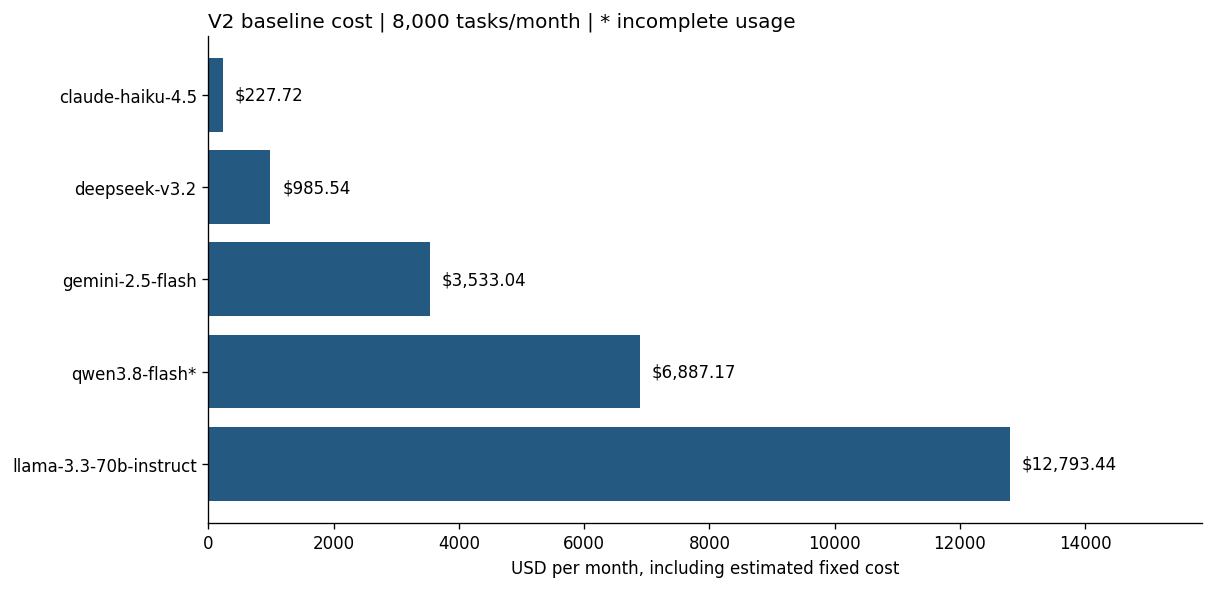

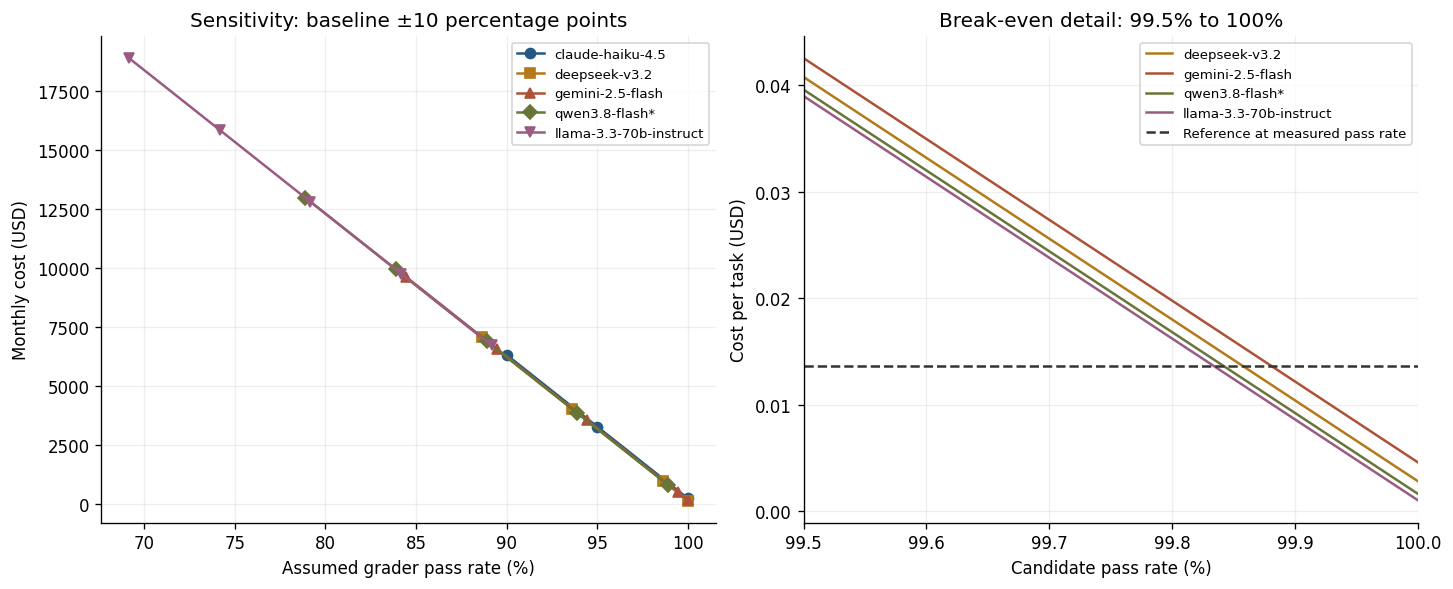

In [ ]:
plt.rcParams.update({"font.size":10,"axes.spines.top":False,"axes.spines.right":False,"figure.dpi":120})
colors = ["#245A81", "#B47918", "#AD5238", "#697537", "#9A5B82"]
fig_cost, ax = plt.subplots(figsize=(10,4.8),layout="constrained")
view = base.sort_values("monthly_total")
ax.barh(view["label"],view["monthly_total"],color="#245A81")
ax.invert_yaxis()
for i,v in enumerate(view["monthly_total"]): ax.text(v+view["monthly_total"].max()*0.015,i,f"${v:,.2f}",va="center")
ax.set_xlim(0,view["monthly_total"].max()*1.24)
ax.set_xlabel("USD per month, including estimated fixed cost")
ax.set_title(f"V2 baseline cost | {VOLUME:,} tasks/month | * incomplete usage",loc="left")
plt.show()

fig_sens, axes = plt.subplots(1,2,figsize=(12,4.8),layout="constrained")
for i,r in enumerate(records):
    d=sensitivity_table[sensitivity_table["model"]==r["model"]].drop_duplicates("success")
    axes[0].plot(d["success"]*100,d["monthly_total"],marker=["o","s","^","D","v"][i%5],color=colors[i%5],label=r["label"])
    if r["model"] != reference["model"]:
        xs=[99.5+j*0.5/100 for j in range(101)]
        axes[1].plot(xs,[cost_per_successful_task(r["layer1"],p/100,FAILURE) for p in xs],color=colors[i%5],label=r["label"])
axes[0].set(xlabel="Assumed grader pass rate (%)",ylabel="Monthly cost (USD)",title="Sensitivity: baseline ±10 percentage points")
axes[0].legend(fontsize=8)
axes[1].axhline(E,color="#333333",linestyle="--",label="Reference at measured pass rate")
axes[1].set(xlabel="Candidate pass rate (%)",ylabel="Cost per task (USD)",title="Break-even detail: 99.5% to 100%",xlim=(99.5,100))
axes[1].legend(fontsize=8)
for ax in axes: ax.grid(alpha=.2)
plt.show()